In [1]:
import subprocess
subprocess.run(["pip", "install", "matplotlib", "seaborn", "pandas"], 
               capture_output=True)
print("Libraries ready!")

Libraries ready!


In [2]:
import pandas as pd
import glob
import os

# Find all CSV files in your raw data folder
csv_files = glob.glob("data/raw/*.csv")
print(f"Found {len(csv_files)} CSV file(s):")
for f in csv_files:
    print(" -", f)

Found 0 CSV file(s):


In [3]:
import os

# Check where Jupyter thinks you are right now
print("Current directory:", os.getcwd())

# List everything in the current folder
print("\nFiles/folders here:")
for item in os.listdir("."):
    print(" -", item)

Current directory: C:\Users\DELL\Desktop\aqi-project\notebooks

Files/folders here:
 - .ipynb_checkpoints
 - Untitled.ipynb


In [4]:
import os
os.chdir(r"C:\Users\DELL\Desktop\aqi-project")
print("Now in:", os.getcwd())

Now in: C:\Users\DELL\Desktop\aqi-project


In [5]:
import glob

csv_files = glob.glob("data/raw/*.csv")
print(f"Found {len(csv_files)} CSV file(s):")
for f in csv_files:
    print(" -", f)
    

Found 1 CSV file(s):
 - data/raw\kathmandu_aqi_20260609.csv


In [6]:
# Load the most recent CSV file
df = pd.read_csv(csv_files[-1])

# Preview the first 5 rows
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 94 rows, 8 columns


,datetime,parameter,value,unit,location_id,location,latitude,longitude
0,2026-06-09T14:15:00Z,pm25,26.00000,µg/m³,3459,Embassy Kathmandu,27.738703,85.336206
1,2025-03-24T14:15:00Z,pm25,71.00000,µg/m³,3460,Phora Durbar Kathman,27.712464,85.315703
2,2025-01-13T23:00:00Z,pm10,78.27381,µg/m³,1236017,"Dhathutole, Handigaun",27.727502,85.330135
3,2026-06-01T04:00:00Z,um003,7646.00000,particles/cm³,1236017,"Dhathutole, Handigaun",27.727502,85.330135
4,2026-06-01T04:00:00Z,pm25,47.70000,µg/m³,1236017,"Dhathutole, Handigaun",27.727502,85.330135


In [7]:
# Convert the date column to proper datetime format
df['date'] = pd.to_datetime(df['date'], utc=True)

# Sort by date
df = df.sort_values('date')

# See what pollutants you have
print("Pollutants in your data:")
print(df['parameter'].value_counts())

KeyError: 'date'

In [8]:
print("Column names in your CSV:")
print(df.columns.tolist())

print("\nFirst 2 rows:")
df.head(2)

Column names in your CSV:
['datetime', 'parameter', 'value', 'unit', 'location_id', 'location', 'latitude', 'longitude']

First 2 rows:


,datetime,parameter,value,unit,location_id,location,latitude,longitude
0,2026-06-09T14:15:00Z,pm25,26.0,µg/m³,3459,Embassy Kathmandu,27.738703,85.336206
1,2025-03-24T14:15:00Z,pm25,71.0,µg/m³,3460,Phora Durbar Kathman,27.712464,85.315703


In [9]:
# Convert the date column to proper datetime format
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)

# Sort by date
df = df.sort_values('datetime')

# See what pollutants you have
print("Pollutants in your data:")
print(df['parameter'].value_counts())

Pollutants in your data:
parameter
pm25                20
pm1                 18
relativehumidity    18
temperature         18
um003               18
pm10                 2
Name: count, dtype: int64


Matplotlib is building the font cache; this may take a moment.


PM2.5 readings: 20


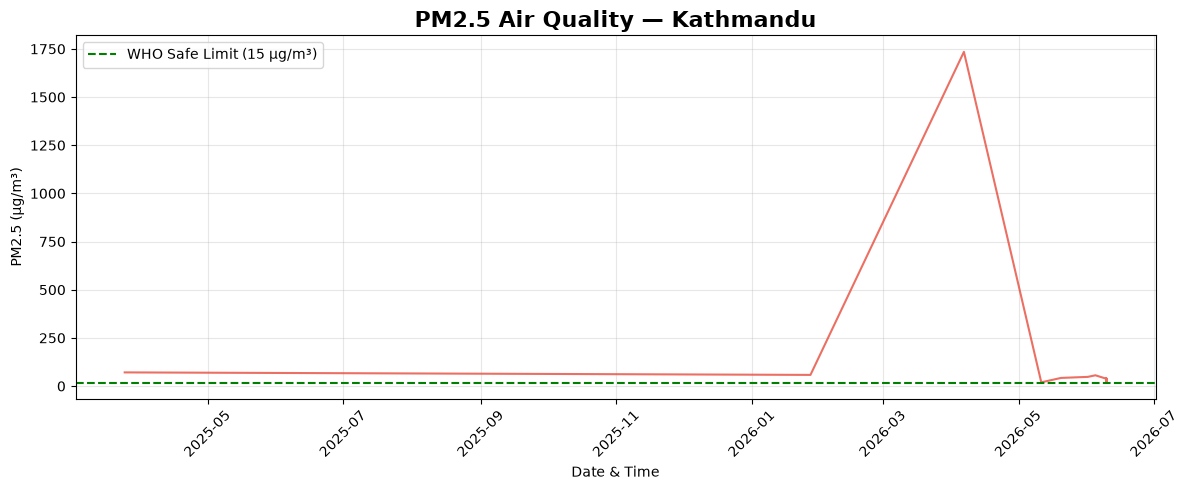

Chart saved!


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter for PM2.5 only
pm25 = df[df['parameter'] == 'pm25'].copy()

print(f"PM2.5 readings: {len(pm25)}")

# Create the chart
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(pm25['datetime'], pm25['value'], 
        color='#e74c3c', linewidth=1.5, alpha=0.8)

# Add WHO safe limit line (15 µg/m³ for PM2.5)
ax.axhline(y=15, color='green', linestyle='--', 
           linewidth=1.5, label='WHO Safe Limit (15 µg/m³)')

# Labels and formatting
ax.set_title('PM2.5 Air Quality — Kathmandu', fontsize=16, fontweight='bold')
ax.set_xlabel('Date & Time')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('data/raw/pm25_chart.png', dpi=150)
plt.show()
print("Chart saved!")

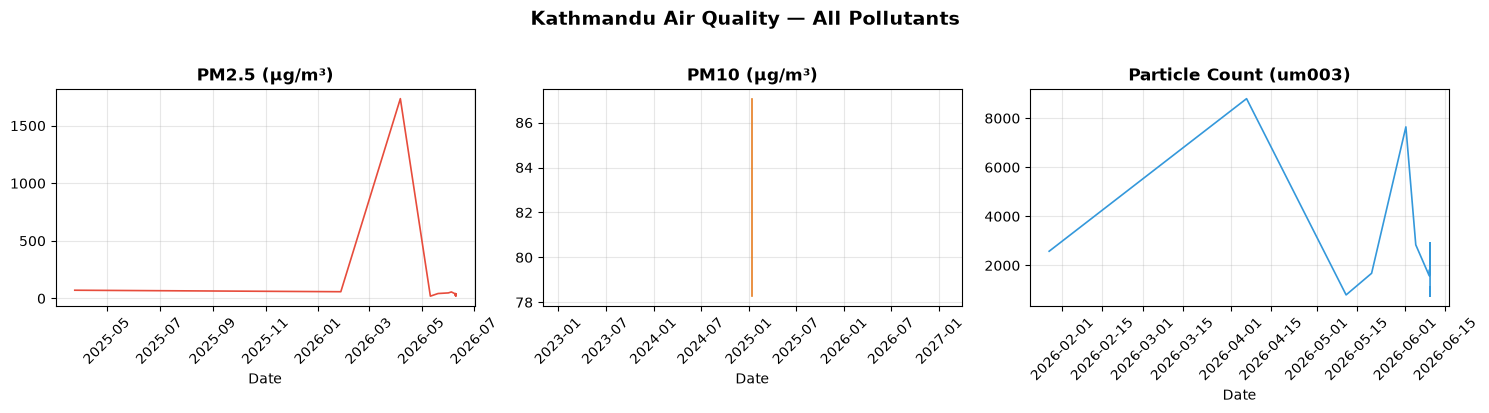

All pollutants chart saved!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pollutants = [
    ('pm25',  '#e74c3c', 'PM2.5 (µg/m³)'),
    ('pm10',  '#e67e22', 'PM10 (µg/m³)'),
    ('um003', '#3498db', 'Particle Count (um003)'),
]

for ax, (param, color, label) in zip(axes, pollutants):
    subset = df[df['parameter'] == param]
    if len(subset) > 0:
        ax.plot(subset['datetime'], subset['value'], color=color, linewidth=1.2)
        ax.set_title(label, fontweight='bold')
        ax.set_xlabel('Date')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
        ax.set_title(label)

plt.suptitle('Kathmandu Air Quality — All Pollutants', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/raw/all_pollutants_chart.png', dpi=150)
plt.show()
print("All pollutants chart saved!")